In [1]:
from pathlib import Path
from CodeBot.tokenizer import BPETokenizer

codebot_dir = Path('CodeBot')

tokenizer = BPETokenizer.load_from(codebot_dir / 'merge_rules.pkl')

print("처음 학습된 10개:")
for token_id in range(256, 266):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode("utf-8", errors="replace")
    print(f"  ID {token_id}: '{text}'")

print("마지막에 학습된 10개:")
for token_id in range(tokenizer.vocab_size - 10, tokenizer.vocab_size):
    byte_seq = tokenizer.id_to_bytes[token_id]
    text = byte_seq.decode("utf-8", errors="replace")
    print(f"  ID {token_id}: '{text}'")

sample_text = (codebot_dir / 'tiny_codes.txt').read_text(encoding='utf-8')[:10000]
byte_count = len(sample_text.encode("utf-8"))
ids = tokenizer.encode(sample_text)
ids_count = len(ids)
compression_ratio = byte_count / ids_count

print("바이트 수:", byte_count)
print("토큰 수:", ids_count)
print("압축률: ", compression_ratio)


처음 학습된 10개:
  ID 256: '  '
  ID 257: '    '
  ID 258: 'in'
  ID 259: '
    '
  ID 260: 'te'
  ID 261: '= '
  ID 262: 'en'
  ID 263: 'or'
  ID 264: ', '
  ID 265: 're'
마지막에 학습된 10개:
  ID 990: 'letter'
  ID 991: 'ing the '
  ID 992: 'ce '
  ID 993: '# Code execute'
  ID 994: 'message'
  ID 995: 'lask'
  ID 996: 'tw'
  ID 997: ''''
  ID 998: 'code '
  ID 999: 'ression'
바이트 수: 10000
토큰 수: 4286
압축률:  2.3331777881474567


In [2]:
import numpy as np

bin_path = codebot_dir / 'tiny_codes.bin'
if bin_path.exists():
    ids_array = np.fromfile(bin_path, dtype=np.uint16)
    print(f'기존 tiny_codes.bin 사용: {len(ids_array):,}개 토큰')
else:
    text = (codebot_dir / 'tiny_codes.txt').read_text(encoding='utf-8')
    ids = tokenizer.encode(text, show_progress=True)
    ids_array = np.array(ids, dtype=np.uint16)
    ids_array.tofile(bin_path)
    print(f'tiny_codes.bin 저장 완료: {len(ids_array):,}개 토큰')

기존 tiny_codes.bin 사용: 2,316,979개 토큰


In [3]:
import sys
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.nn.functional as F
import matplotlib.pyplot as plt
from itertools import cycle
from tqdm import tqdm
from CodeBot.model import GPT
from CodeBot.utils import get_device

device = get_device()
data_path = codebot_dir / 'tiny_codes.bin'
tokenizer_path = codebot_dir / 'merge_rules.pkl'
model_save_path = codebot_dir / 'model_pretrain.pt'

context_len = 256
vocab_size = 1000
batch_size = 32
learning_rate = 3e-4

max_iters = 20000
embed_dim = 384
n_head = 6
n_layer = 6
ff_dim = 4 * embed_dim
dropout_rate = 0.1

In [4]:
class TokenDataset(Dataset):
    def __init__(self, tokens, context_len):
        self.tokens = torch.tensor(tokens, dtype=torch.long)
        self.context_len = context_len

    def __len__(self):
        return len(self.tokens) - self.context_len

    def __getitem__(self, idx):
        x = self.tokens[idx:idx+self.context_len]
        y = self.tokens[idx+1:idx+self.context_len+1]
        return x, y

In [5]:
ids = np.fromfile(data_path, dtype=np.uint16)
dataset = TokenDataset(ids, context_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

if model_save_path.exists():
    model = GPT.load_from(model_save_path, device=device)
    train_iters = 0
    print('기존 model_pretrain.pt를 불러와 사전학습을 생략합니다.')
else:
    model = GPT(
        vocab_size=vocab_size,
        max_context_len=context_len,
        embed_dim=embed_dim,
        n_head=n_head,
        n_layer=n_layer,
        ff_dim=ff_dim,
        dropout_rate=dropout_rate
    ).to(device)
    train_iters = max_iters
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

total_params = sum(p.numel() for p in model.parameters())
print('파라미터수:', total_params)

losses = []
data_iter = cycle(dataloader)  
pbar = tqdm(range(train_iters))

기존 model_pretrain.pt를 불러와 사전학습을 생략합니다.
파라미터수: 11121640


0it [00:00, ?it/s]

In [6]:
for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), batch_y.view(-1))

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

if losses:
    plt.figure(figsize=(10, 6))
    plt.plot(losses)
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig(codebot_dir / 'loss_pretrain.png')
    model.save(model_save_path)
else:
    print('사전학습 생략 완료')

0it [00:00, ?it/s]

사전학습 생략 완료


In [7]:
import sys
sys.path.append('.')

import torch
import torch.nn.functional as F
from CodeBot.model import GPT
from CodeBot.tokenizer import BPETokenizer
from CodeBot.utils import get_device
from CodeBot.utils import generate

device = get_device()
print(device)

model_save_path = codebot_dir / 'model_pretrain.pt'
tokenizer_path = codebot_dir / 'merge_rules.pkl'

prompt = 'def'
max_new_tokens = 200
temperature = 1.0

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_save_path, device = device)


cuda


In [8]:
for i in range(5):
    print(i)
    generated_text = generate(
        model = model,
        tokenizer = tokenizer,
        prompt = prompt,
        max_new_tokens = max_new_tokens,
        temperature = temperature
    )

    print(generated_text)

0
default based on number user. In summary, in Python that range() will take input a number using the `float()` function. The program will prompt the user for the number then used by the function and calculate the total taken. You can calculate the calculate the area of a circle.

You can use this function (also to activate the calculator base purpose. For example, the function can be used to iterate over a list of along its values. It calculates the area of a circle.

You can use it:

`!=
<|endoftext|>
On
1
default details
class Details():
    # TODO: Define the details
class Descriptor: Description: Description stored
     methods

    Description: Description: Description stored
    Returns
    
    --------
    description: LabelNight
    Returns
    ------
    bool
    """
    def __init__(self):
        provider = Description()
        self.poptions = {
            '+'-':'
            |'*':'/',
                    '*' - 1,
                    '*':/',
                    '*':'/',


In [9]:
import sys
sys.path.append('.')

import json
from CodeBot.tokenizer import BPETokenizer

tokenizer = BPETokenizer.load_from(codebot_dir / 'merge_rules.pkl')

with (codebot_dir / 'tiny_codes_sft.json').open(encoding='utf-8') as f:
    data = json.load(f)

item = data[0]
print(item)

text = f"### Instruction:\n{item['instruction']}\n\n### Response:\n{item['response']}<|endoftext|>"

print(text)

ids = tokenizer.encode(text)
print(ids)

{'instruction': 'Hello', 'response': 'Hello. What can I help you with?'}
### Instruction:
Hello

### Response:
Hello. What can I help you with?<|endoftext|>
[35, 35, 282, 620, 449, 117, 415, 58, 10, 913, 303, 35, 35, 282, 572, 472, 271, 278, 58, 10, 913, 469, 87, 104, 811, 99, 562, 73, 32, 104, 361, 112, 32, 121, 613, 32, 574, 63, 298, 62]


In [10]:
import sys
sys.path.append('.')

from itertools import cycle
import json
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
from tqdm import tqdm
from CodeBot.model import GPT
from CodeBot.tokenizer import BPETokenizer
from CodeBot.utils import get_device


In [11]:
device = get_device()
print(device)

data_path = codebot_dir / 'tiny_codes_sft.json'
tokenizer_path = codebot_dir / 'merge_rules.pkl'
pretrain_model_path = codebot_dir / 'model_pretrain.pt'
sft_model_save_path = codebot_dir / 'model_sft.pt'

context_len = 256
batch_size = 32
learning_rate = 3e-4
max_iters = 500



cuda


In [12]:
class SFTDataset(Dataset):
    def __init__(self, data_path, tokenizer, context_len):
        self.tokenizer = tokenizer
        self.context_len = context_len
        self.samples = []

        with open(data_path) as f:
            data = json.load(f)

        for item in data:
            ids, labels = self._create_sample(item['instruction'], item['response'])
            self.samples.append((ids, labels))

    def _create_sample(self, instruction, response):
        prompt = f"### Instruction:\n{instruction}\n\n### Response:\n"
        response = f"{response}<|endoftext|>"

        prompt_ids = self.tokenizer.encode(prompt)
        response_ids = self.tokenizer.encode(response)

        ids = prompt_ids + response_ids
        labels = [-100] * len(prompt_ids) + response_ids

        ids = ids[:-1]
        labels = labels[1:]

        pad_len = self.context_len - len(ids)
        if pad_len > 0:
            ids = ids + [0] * pad_len  
            labels = labels + [-100] * pad_len
        elif pad_len < 0:
            ids = ids[:self.context_len]
            labels = labels[:self.context_len]

        return ids, labels

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        ids, labels = self.samples[idx]
        return torch.tensor(ids, dtype=torch.long), \
               torch.tensor(labels, dtype=torch.long)


In [13]:
tokenizer = BPETokenizer.load_from(tokenizer_path)
dataset = SFTDataset(data_path, tokenizer, context_len)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

model = GPT.load_from(pretrain_model_path, device=device)
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

losses = []
data_iter = cycle(dataloader)


100%|██████████| 500/500 [00:58<00:00,  8.48it/s, loss=0.0723]


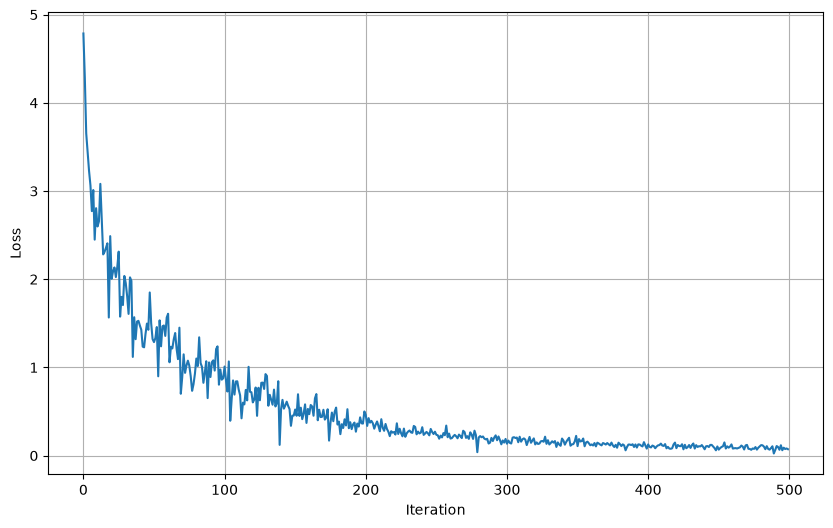

In [14]:
pbar = tqdm(range(max_iters))

for i in pbar:
    batch_x, batch_y = next(data_iter)
    batch_x, batch_y = batch_x.to(device), batch_y.to(device)

    logits = model(batch_x)
    loss = F.cross_entropy(
        logits.view(-1, logits.size(-1)),
        batch_y.view(-1),
        ignore_index=-100  
    )

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())
    pbar.set_postfix({'loss': f'{loss.item():.4f}'})

plt.figure(figsize=(10, 6))
plt.plot(losses)
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)
plt.savefig('loss_sft.png')

model.save(sft_model_save_path)

In [ ]:
device = get_device()
model_path = 'codebot/model_sft.pt'
tokenizer_path = 'codebot/merge_rules.pkl'
max_new_tokens = 200
temperature = 1.0

def format_prompt(user_message):
    return f"### Instruction:\n{user_message}\n\n### Response:\n"

tokenizer = BPETokenizer.load_from(tokenizer_path)
model = GPT.load_from(model_path, device=device)

while True:
    user_input = input("\nYou: ").strip()

    if not user_input:
        continue

    prompt = format_prompt(user_input)
    response = generate(model, tokenizer, prompt, max_new_tokens, temperature)

    if "### Response:" in response:
        response = response.split("### Response:")[-1].strip()

    if "\n" in response:
        print(f"Bot:\n{response}")
    else:
        print(f"Bot: {response}")